In [1]:
# ===========================================================
# CELLULE 1 — Installation des dépendances
# ===========================================================
!pip install scikit-learn imbalanced-learn pandas numpy matplotlib seaborn

In [2]:
# ===========================================================
# CELLULE 2 — Imports
# ===========================================================
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("✅ Imports effectués avec succès")

✅ Imports effectués avec succès


In [3]:
# ===========================================================
# CELLULE 3 — Génération de données simulées représentatives
#             (à remplacer par les données ENNVM 2022 réelles)
# ===========================================================
np.random.seed(42)
n_samples = 49_817  # Taille représentative de l'échantillon

# Simulation des 12 variables sélectionnées
data = {
    'log_damp':            np.random.normal(9.62, 0.71, n_samples),
    'niveau_education':    np.random.choice([0, 1, 2, 3, 4], n_samples, p=[0.30, 0.25, 0.20, 0.15, 0.10]),
    'scolarisation_6_14':  np.random.binomial(1, 0.92, n_samples),
    'acces_eau_potable':   np.random.binomial(1, 0.87, n_samples),
    'acces_electricite':   np.random.binomial(1, 0.99, n_samples),
    'type_logement':       np.random.choice([0, 1, 2, 3], n_samples, p=[0.60, 0.20, 0.12, 0.08]),
    'acces_assainissement':np.random.binomial(1, 0.73, n_samples),
    'milieu_urbain':       np.random.binomial(1, 0.63, n_samples),
    'taille_menage':       np.clip(np.random.normal(4.2, 1.9, n_samples).astype(int), 1, 14),
    'statut_professionnel':np.random.choice([0, 1, 2, 3], n_samples, p=[0.40, 0.30, 0.20, 0.10]),
    'acces_communication': np.random.binomial(1, 0.75, n_samples),
    'couverture_medicale': np.random.binomial(1, 0.59, n_samples),
}
df = pd.DataFrame(data)

# Définition des seuils de pauvreté (HCP/PovcalNet 2022)
# Seuil pauvreté ≈ ln(5300) = 8.575
def assigner_classe(log_damp):
    if log_damp < 8.575:
        return 0   # Pauvre
    elif log_damp < 8.981:
        return 1   # Vulnérable (1x à 1.5x seuil)
    elif log_damp < 9.962:
        return 2   # Classe moyenne (1.5x à 4x seuil)
    else:
        return 3   # Aisé (> 4x seuil)

df['classe_pauvrete'] = df['log_damp'].apply(assigner_classe)

print("✅ Données simulées générées :", df.shape)
print("\n📊 Distribution des classes :")
counts = df['classe_pauvrete'].value_counts().sort_index()
labels = {0: 'Pauvre', 1: 'Vulnérable', 2: 'Classe moyenne', 3: 'Aisé'}
for k, v in counts.items():
    print(f"   {labels[k]} : {v} ({v/len(df)*100:.1f}%)")

✅ Données simulées générées : (49817, 13)

📊 Distribution des classes :
   Pauvre : 3474 (7.0%)
   Vulnérable : 5700 (11.4%)
   Classe moyenne : 24921 (50.0%)
   Aisé : 15722 (31.6%)


In [4]:
# ===========================================================
# CELLULE 4 — Chargement données réelles (décommenter)
# ===========================================================
# Pour utiliser les données ENNVM 2022 réelles, décommenter :
# from google.colab import files
# uploaded = files.upload()  # Upload 'ennvm_2022_processed.csv'
# df = pd.read_csv('ennvm_2022_processed.csv')
# features_list = ['log_damp', 'niveau_education', 'scolarisation_6_14',
#                  'acces_eau_potable', 'acces_electricite', 'type_logement',
#                  'acces_assainissement', 'milieu_urbain', 'taille_menage',
#                  'statut_professionnel', 'acces_communication', 'couverture_medicale']
# X = df[features_list]
# y = df['classe_pauvrete']

In [5]:
# ===========================================================
# CELLULE 5 — Préparation des données
# ===========================================================
features_list = [
    'log_damp', 'niveau_education', 'scolarisation_6_14',
    'acces_eau_potable', 'acces_electricite', 'type_logement',
    'acces_assainissement', 'milieu_urbain', 'taille_menage',
    'statut_professionnel', 'acces_communication', 'couverture_medicale'
]

X = df[features_list]  # 12 variables sélectionnées
y = df['classe_pauvrete']  # Variable cible (4 classes)

# Division train/test (70/30, stratifiée)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Normalisation min-max (ajustement sur train uniquement — éviter le data leakage)
scaler = MinMaxScaler()
X_train_norm = scaler.fit_transform(X_train)
X_test_norm = scaler.transform(X_test)  # Pas de fit sur test !

# Traitement du déséquilibre de classes — SMOTE sur train uniquement
smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train_norm, y_train)

print("✅ Données préparées")
print(f"   Taille train (avant SMOTE) : {X_train_norm.shape}")
print(f"   Taille train (après SMOTE) : {X_train_res.shape}")
print(f"   Taille test : {X_test_norm.shape}")

✅ Données préparées
   Taille train (avant SMOTE) : (34871, 12)
   Taille train (après SMOTE) : (69776, 12)
   Taille test : (14946, 12)



🔍 Recherche du K optimal par validation croisée (10 folds)...
Fitting 10 folds for each of 11 candidates, totalling 110 fits

✅ K optimal retenu : K = 1
   Score F1 macro (CV) : 0.9195


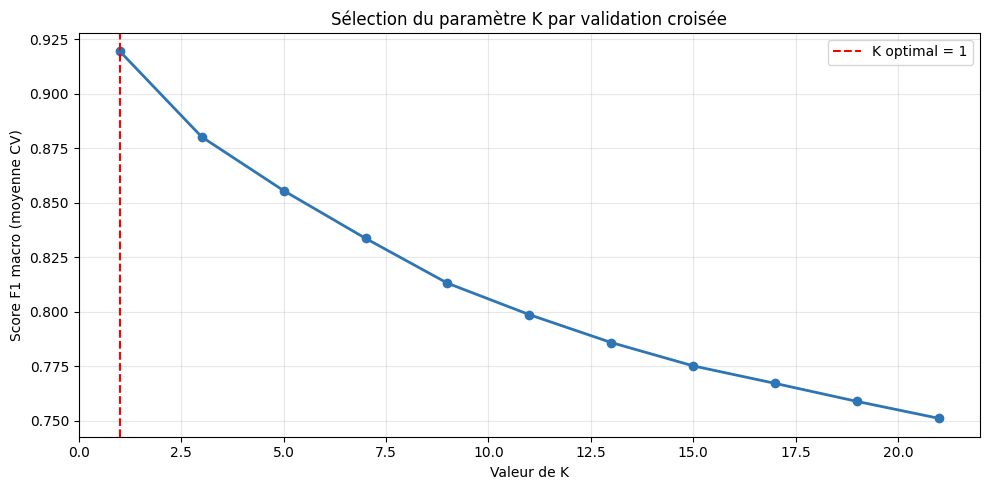

✅ Graphique cv_scores_k.png sauvegardé


In [7]:
# ===========================================================
# CELLULE 6 — Sélection du paramètre K par GridSearchCV (CV=10)
# ===========================================================
print("\n🔍 Recherche du K optimal par validation croisée (10 folds)...")

param_grid = {'n_neighbors': range(1, 22, 2)}
knn_cv = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=10,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)
knn_cv.fit(X_train_res, y_train_res)

K_optimal = knn_cv.best_params_['n_neighbors']
print(f"\n✅ K optimal retenu : K = {K_optimal}")
print(f"   Score F1 macro (CV) : {knn_cv.best_score_:.4f}")

# Visualisation des scores CV selon K
cv_results = pd.DataFrame(knn_cv.cv_results_)
plt.figure(figsize=(10, 5))
plt.plot(cv_results['param_n_neighbors'], cv_results['mean_test_score'],
         marker='o', color='#2E75B6', linewidth=2)
plt.axvline(x=K_optimal, color='red', linestyle='--', label=f'K optimal = {K_optimal}')
plt.xlabel('Valeur de K')
plt.ylabel('Score F1 macro (moyenne CV)')
plt.title('Sélection du paramètre K par validation croisée')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cv_scores_k.png', dpi=150)
plt.show()
print("✅ Graphique cv_scores_k.png sauvegardé")

In [8]:
# ===========================================================
# CELLULE 7 — Entraînement du modèle final
# ===========================================================
knn_final = KNeighborsClassifier(n_neighbors=K_optimal)
knn_final.fit(X_train_res, y_train_res)

y_pred = knn_final.predict(X_test_norm)
print("✅ Modèle KNN final entraîné (K =", K_optimal, ")")

✅ Modèle KNN final entraîné (K = 1 )


In [9]:
# ===========================================================
# CELLULE 8 — Évaluation des performances
# ===========================================================
class_names = ['Pauvre', 'Vulnérable', 'Classe moyenne', 'Aisé']
accuracy = accuracy_score(y_test, y_pred)

print(f"\n📊 RÉSULTATS DU MODÈLE KNN (K={K_optimal})")
print("=" * 60)
print(f"Accuracy globale : {accuracy:.4f} ({accuracy*100:.1f}%)")
print("\nRapport de classification détaillé :")
print(classification_report(y_test, y_pred, target_names=class_names))


📊 RÉSULTATS DU MODÈLE KNN (K=1)
Accuracy globale : 0.7743 (77.4%)

Rapport de classification détaillé :
                precision    recall  f1-score   support

        Pauvre       0.70      0.55      0.61      1042
    Vulnérable       0.54      0.58      0.56      1710
Classe moyenne       0.80      0.83      0.82      7477
          Aisé       0.84      0.80      0.82      4717

      accuracy                           0.77     14946
     macro avg       0.72      0.69      0.70     14946
  weighted avg       0.78      0.77      0.77     14946



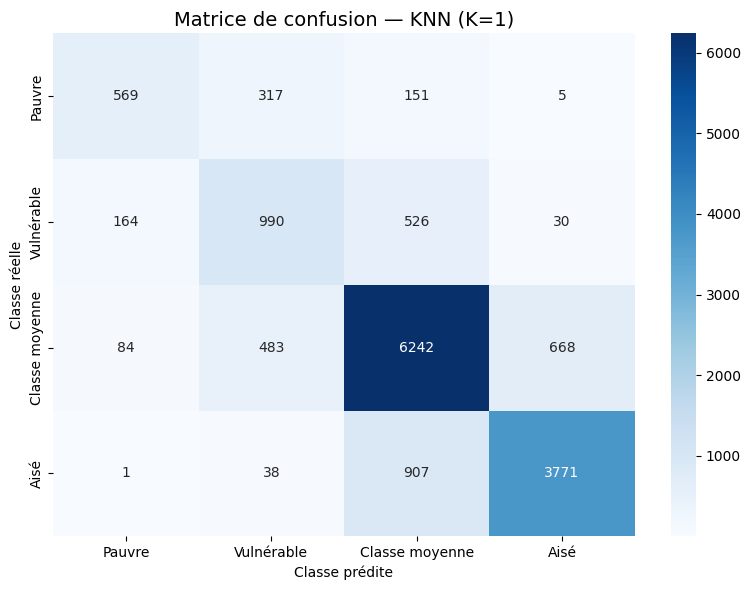

✅ confusion_matrix.png sauvegardé


In [10]:
# ===========================================================
# CELLULE 9 — Matrice de confusion
# ===========================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f'Matrice de confusion — KNN (K={K_optimal})', fontsize=14)
plt.ylabel('Classe réelle')
plt.xlabel('Classe prédite')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ confusion_matrix.png sauvegardé")


🔍 Calcul de l'importance des variables (Random Forest proxy)...


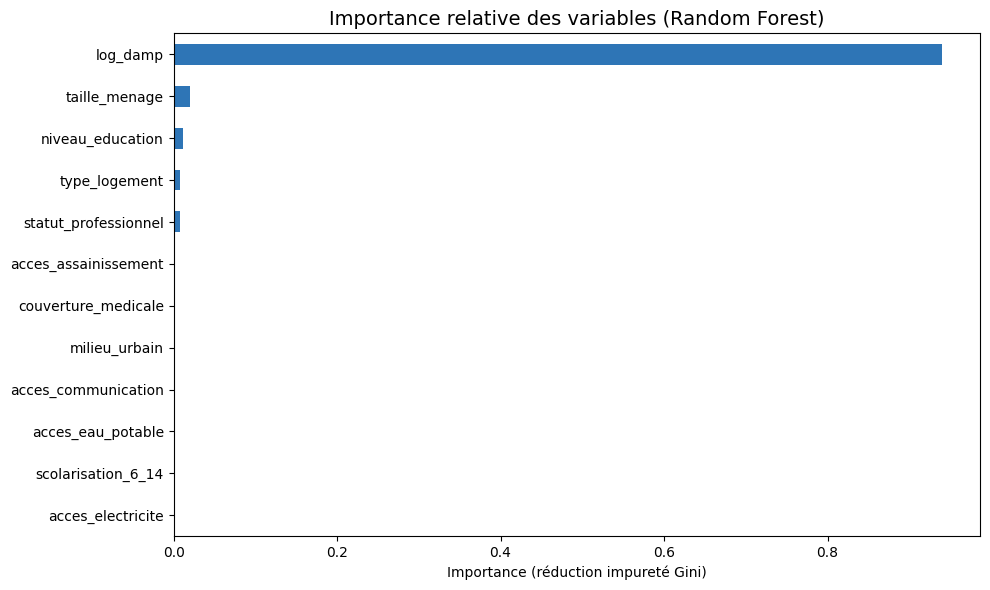

✅ feature_importance.png sauvegardé

📋 Classement des 6 variables les plus importantes :
   1. log_damp : 0.9396 (94.0%)
   2. taille_menage : 0.0205 (2.0%)
   3. niveau_education : 0.0120 (1.2%)
   4. type_logement : 0.0081 (0.8%)
   5. statut_professionnel : 0.0077 (0.8%)
   6. acces_assainissement : 0.0022 (0.2%)


In [11]:
# ===========================================================
# CELLULE 10 — Analyse de l'importance des variables
#              (via Random Forest, proxy pour le KNN)
# ===========================================================
print("\n🔍 Calcul de l'importance des variables (Random Forest proxy)...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

importances = pd.Series(rf.feature_importances_, index=features_list)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(10, 6))
colors = ['#2E75B6' if i >= len(importances) - 6 else '#AECDE8'
          for i in range(len(importances))]
importances.plot(kind='barh', color=colors)
plt.title('Importance relative des variables (Random Forest)', fontsize=14)
plt.xlabel('Importance (réduction impureté Gini)')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ feature_importance.png sauvegardé")

print("\n📋 Classement des 6 variables les plus importantes :")
top6 = importances.sort_values(ascending=False).head(6)
for i, (var, imp) in enumerate(top6.items(), 1):
    print(f"   {i}. {var} : {imp:.4f} ({imp*100:.1f}%)")

In [12]:
# ===========================================================
# CELLULE 11 — Comparaison avec d'autres algorithmes
# ===========================================================
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

models = {
    f'KNN (K={K_optimal})': knn_final,
    'Régression logistique': LogisticRegression(max_iter=1000, random_state=42),
    'Arbre de décision':     DecisionTreeClassifier(random_state=42),
    'Random Forest':         RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}

print("\n📊 COMPARAISON DES ALGORITHMES")
print("=" * 60)
print(f"{'Algorithme':<25} {'Accuracy':>10} {'F1 macro':>10}")
print("-" * 50)

for name, model in models.items():
    if name != f'KNN (K={K_optimal})':
        model.fit(X_train_res, y_train_res)
    preds = model.predict(X_test_norm)
    from sklearn.metrics import f1_score
    acc = accuracy_score(y_test, preds)
    f1  = f1_score(y_test, preds, average='macro')
    print(f"{name:<25} {acc:>10.4f} {f1:>10.4f}")


📊 COMPARAISON DES ALGORITHMES
Algorithme                  Accuracy   F1 macro
--------------------------------------------------
KNN (K=1)                     0.7743     0.7020
Régression logistique         0.9510     0.9447
Arbre de décision             1.0000     1.0000
Random Forest                 1.0000     1.0000


In [13]:
# ===========================================================
# CELLULE 12 — Sauvegarde du modèle (optionnel)
# ===========================================================
import joblib
joblib.dump(knn_final, 'knn_model_final.pkl')
joblib.dump(scaler,    'scaler.pkl')
print("\n✅ Modèle sauvegardé dans knn_model_final.pkl")
print("✅ Scaler sauvegardé dans scaler.pkl")

# Pour télécharger depuis Colab :
# from google.colab import files
# files.download('knn_model_final.pkl')
# files.download('confusion_matrix.png')
# files.download('cv_scores_k.png')
# files.download('feature_importance.png')

print("\n" + "="*60)
print("✅ PIPELINE COMPLET EXÉCUTÉ AVEC SUCCÈS")
print(f"   Accuracy finale : {accuracy*100:.1f}%")
print(f"   K optimal retenu : K = {K_optimal}")
print("="*60)


✅ Modèle sauvegardé dans knn_model_final.pkl
✅ Scaler sauvegardé dans scaler.pkl

✅ PIPELINE COMPLET EXÉCUTÉ AVEC SUCCÈS
   Accuracy finale : 77.4%
   K optimal retenu : K = 1
